In [2]:
import pandas as pd
from IPython.display import display, Markdown 
from collections import Counter 

In [3]:
!find . -name "*.dta"

./RLMS_HH_1994_2024_eng.dta
./MWandOccupations/data/raw/RLMS_HH_1994_2024_eng.dta
./MWandOccupations/data/raw/RLMS_IND_1994_2024_eng.dta


In [4]:
!ls MWandOccupations/data/raw

2026_Min_wage.xlsx                 russia_minimum_wage_2000_2026.xlsx
RLMS_HH_1994_2024_eng.dta          ~$2026_Min_wage.xlsx
RLMS_IND_1994_2024_eng.dta         ~$min_wage_ru.xlsx
Subs_min.xlsx                      БД_2024_eng_ind_codebook.sav
min_wage_ru.xlsx


In [5]:
import pandas as pd

# Regional Data
df1 = pd.read_stata('/Users/mac/Desktop/homework/homework/MWandOccupations/data/raw/RLMS_HH_1994_2024_eng.dta', 
                   convert_categoricals=False,
                   convert_dates=False,
                   preserve_dtypes=True)
df1.columns = [col.lower() for col in df1.columns]

In [6]:
import pandas as pd

# Minimum Wage Data
df2 = pd.read_stata('/Users/mac/Desktop/homework/homework/MWandOccupations/data/raw/RLMS_IND_1994_2024_eng.dta', 
                   convert_categoricals=False,
                   convert_dates=False,
                   preserve_dtypes=True)
df2.columns = [col.lower() for col in df2.columns]   

In [7]:
import pyreadstat 

# Read the SPSS file
df_meta, meta = pyreadstat.read_sav("/Users/mac/Desktop/homework/homework/MWandOccupations/data/raw/БД_2024_eng_ind_codebook.sav")

In [8]:
#df_meta[df_meta.v2a == 'j4_1']
#df_meta[df_meta.index >= 96].head(60)
#for i in df_meta.index:
    #print(df_meta[df_meta.index == i])

              year      min_wage
count  2457.000000   2457.000000
mean   2013.000000   8406.734367
std       7.790466   7879.633388
min    2000.000000    132.000000
25%    2006.000000   1100.000000
50%    2013.000000   5965.000000
75%    2020.000000  12431.000000
max    2026.000000  46058.100000
Years covered: 2000 - 2026


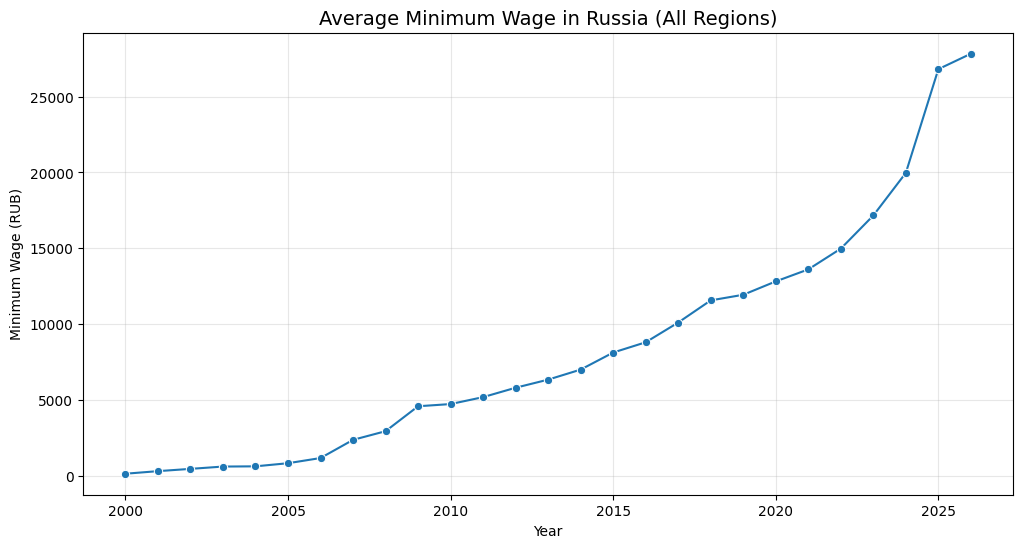

['Russian Federation' 'Belgorod Region' 'Bryansk Region' 'Vladimir Region'
 'Voronezh Region' 'Ivanovo Region' 'Kaluga Region' 'Kostroma Region'
 'Kursk Region' 'Lipetsk Region' 'Moscow Region' 'Oryol Region'
 'Ryazan Region' 'Smolensk Region' 'Tambov Region' 'Tver Region'
 'Tula Region' 'Yaroslavl Region' 'Moscow (Federal City)'
 'Republic of Komi' 'Arkhangelsk Region' 'Nenets Autonomous Okrug'
 'Vologda Region' 'Kaliningrad Region' 'Leningrad Region'
 'Murmansk Region' 'Novgorod Region' 'Pskov Region'
 'Saint Petersburg (Federal City)' 'Republic of Adygea'
 'Republic of Kalmykia' 'Republic of Crimea' 'Krasnodar Krai'
 'Astrakhan Region' 'Volgograd Region' 'Rostov Region'
 'Sevastopol (Federal City)' 'Republic of Dagestan'
 'Republic of Ingushetia' 'Kabardino-Balkarian Republic'
 'Karachay-Cherkess Republic' 'Republic of North Ossetia-Alania'
 'Chechen Republic' 'Stavropol Krai' 'Republic of Bashkortostan'
 'Republic of Mari El' 'Republic of Mordovia' 'Republic of Tatarstan'
 'Udmurt 

In [9]:
# Minimum Wage Data
df_mw = pd.read_excel('/Users/mac/Desktop/homework/homework/MWandOccupations/data/raw/min_wage_ru.xlsx', sheet_name = 'mw_panel')
 
print(df_mw.describe())
print(f"Years covered: {df_mw['year'].min()} - {df_mw['year'].max()}")

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average minimum wage across all regions by year
national_avg = df_mw.groupby('year')['min_wage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=national_avg, x='year', y='min_wage', marker='o')
plt.title('Average Minimum Wage in Russia (All Regions)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Minimum Wage (RUB)')
plt.grid(True, alpha=0.3)
plt.savefig('Average Minimum Wage in Russia (All Regions).png', dpi=300, bbox_inches='tight')
plt.show()

print(df_mw.region.unique()) 
print(f"Unique regions: {df_mw['region'].nunique()}")

In [10]:
# If the region column has the same values in both dataframes
if 'region' in df1.columns:
    df1 = df1.drop(columns=['region'])  # Remove duplicate column

df_analysis = pd.merge(
    df1,
    df2,
    on=['id_w', 'id_h'],
    how='outer'
) 
  
print(df_analysis.shape) 

(458467, 6034)


In [11]:
df_analysis.region.unique()

array([  1.,   9.,  10.,  12.,  14.,  33.,  39.,  45.,  46.,  47.,  48.,
        52.,  58.,  66.,  67.,  70.,  71.,  72.,  73.,  77.,  84.,  86.,
        89.,  92.,  93., 100., 105., 106., 107., 116., 117., 129., 135.,
       136., 137., 138., 141., 142.,  nan, 161., 200.])

In [12]:
#print(df_analysis.columns.tolist())
[col for col in df_analysis.columns if 'occup' in col]

['occup08']

In [13]:
# Check what professional codes actually exist in your data
print("\n📊 Professional Code Verification:")
if 'occ_2digit' in df_analysis.columns:
    prof_codes_in_data = df_analysis[df_analysis['occ_2digit'].notna()]['occ_2digit'].unique()
    prof_codes_in_data = sorted([int(x) for x in prof_codes_in_data if pd.notna(x)])
    
    print(f"  Unique 2-digit codes in your data: {prof_codes_in_data}")
    
    # Check which professional codes are present
    present_managers = [c for c in [11,12,13,14] if c in prof_codes_in_data]
    present_prof = [c for c in [21,22,23,24,25,26] if c in prof_codes_in_data]
    present_tech = [c for c in [31,32,33,34,35] if c in prof_codes_in_data]
    
    print(f"  Present manager codes: {present_managers}")
    print(f"  Present core professional codes: {present_prof}")
    print(f"  Present technician codes: {present_tech}")


📊 Professional Code Verification:


In [14]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RUSSIA MINIMUM WAGE AND PROFESSIONAL EMPLOYMENT STUDY")
print("="*80)

# ============================================================================
# SECTION 1: LOAD AND CHECK DATA
# ============================================================================

print("\n" + "="*80)
print("SECTION 1: DATA LOADING AND INITIAL EXAMINATION")
print("="*80)

print("\n📊 Raw RLMS Data:")
df_analysis = df_analysis[df_analysis.year >= 2000]
print(f"  Shape: {df_analysis.shape}")
print(f"  Years: {df_analysis['year'].min()} to {df_analysis['year'].max()}")
print(f"  Unique individuals: {df_analysis['idind'].nunique():,}")
print(f"  Unique regions: {df_analysis['region'].nunique()}")

print("\n📊 Minimum Wage Data:")
print(f"  Shape: {df_mw.shape}")
print(f"  Years: {df_mw['year'].min()} to {df_mw['year'].max()}")
print(f"  Unique regions in MW data: {df_mw['region'].nunique()}")

# ============================================================================
# SECTION 2: MATCH RLMS REGIONS TO MINIMUM WAGE REGIONS
# ============================================================================

print("\n" + "="*80)
print("SECTION 2: RLMS TO MINIMUM WAGE REGION MAPPING")
print("="*80)

df_clean = df_analysis.copy()

# RLMS region code → actual federal region (used in MW dataset)
rlms_to_mw_mapping = {
    1:  "Leningrad Region",
    9:  "Krasnodar Krai",
    10: "Udmurt Republic",
    12: "Perm Krai",
    14: "Kaluga Region",
    33: "Tambov Region",
    39: "Volgograd Region",
    45: "Republic of Tatarstan",
    46: "Kurgan Region",
    47: "Orenburg Region",
    48: "Chuvash Republic",
    52: "Stavropol Krai",
    58: "Altai Krai",
    66: "Krasnoyarsk Krai",
    67: "Tver Region",
    70: "Saratov Region",
    71: "Tomsk Region",
    72: "Lipetsk Region",
    73: "Krasnoyarsk Krai",
    77: "Kabardino-Balkarian Republic",
    84: "Altai Krai",
    86: "Khanty-Mansi Autonomous Okrug",
    89: "Republic of Komi",
    92: "Primorsky Krai",
    93: "Amur Region",
    100: "Saratov Region",
    105: "Republic of Komi",
    106: "Chelyabinsk Region",
    107: "Chelyabinsk Region",
    116: "Nizhny Novgorod Region",
    117: "Penza Region",
    129: "Krasnodar Krai",
    135: "Smolensk Region",
    136: "Tula Region",
    137: "Rostov Region",
    138: "Moscow (Federal City)",
    139: "Moscow (Federal City)",
    140: "Moscow (Federal City)",
    141: "Saint Petersburg (Federal City)",
    142: "Moscow Region",
    161: "Novosibirsk Region",
    200: "Republic of Komi"
}

# Apply mapping
df_clean['mw_region'] = df_clean['region'].map(rlms_to_mw_mapping)

# Check coverage
mapped_pct = df_clean['mw_region'].notna().mean() * 100
print(f"\n✅ Mapping coverage: {mapped_pct:.1f}%")

# Show sample of mapped regions
sample_mapped = df_clean[df_clean['mw_region'].notna()][['region', 'mw_region']].drop_duplicates().head(10)
print("\n📊 Sample mappings (RLMS code -> MW region):")
for _, row in sample_mapped.iterrows():
    print(f"  Region {row['region']} -> {row['mw_region']}")

# ============================================================================
# SECTION 3: CREATE BASIC VARIABLES
# ============================================================================

print("\n" + "="*80)
print("SECTION 3: CORE VARIABLE CREATION")
print("="*80)

missing_codes = [99999996, 99999997, 99999998, 99999999, 88888888] 

# 3.1 OCCUPATION VARIABLES
print("\n3.1 CREATING OCCUPATION VARIABLES")
if 'j2cod08' in df_clean.columns:
    df_clean['j2cod08'] = df_clean['j2cod08'].replace(missing_codes, np.nan)
    
    original_shape = df_clean.shape[0]
    df_clean = df_clean[df_clean['j2cod08'].notna()].copy()
    print(f"  Removed {original_shape - df_clean.shape[0]} rows with missing occupation codes")
    
    df_clean['occ_1digit'] = (df_clean['j2cod08'] // 1000)
    df_clean['occ_2digit'] = (df_clean['j2cod08'] // 100)
    df_clean['occ_3digit'] = (df_clean['j2cod08'] // 10)
    df_clean['occ_4digit'] = df_clean['j2cod08']
    
    for col in ['occ_1digit', 'occ_2digit', 'occ_3digit', 'occ_4digit']:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64')
    
    print(f"✅ Created occupation variables. Shape: {df_clean.shape}")
else:
    print("❌ j2cod08 not found")
    df_clean['occ_1digit'] = np.nan
    df_clean['occ_2digit'] = np.nan
    df_clean['occ_3digit'] = np.nan
    df_clean['occ_4digit'] = np.nan

# 3.2 GENDER
print("\n3.2 CREATING GENDER INDICATOR")
if 'h5' in df_clean.columns:
    df_clean['h5'] = df_clean['h5'].replace(missing_codes, np.nan)
    df_clean['female'] = (df_clean['h5'] == 2).astype(float)
    gender_known = df_clean['h5'].notna()
    if gender_known.any():
        male_pct = (df_clean.loc[gender_known, 'h5'] == 1).mean() * 100
        female_pct = (df_clean.loc[gender_known, 'h5'] == 2).mean() * 100
        print(f"✅ Created female indicator. Male: {male_pct:.1f}%, Female: {female_pct:.1f}%")
    else:
        print("✅ Created female indicator (all missing)")
else:
    print("❌ h5 not found")
    df_clean['female'] = np.nan

# 3.3 AGE AND EDUCATION
print("\n3.3 CREATING DEMOGRAPHIC VARIABLES")
if 'age' in df_clean.columns:
    df_clean['age'] = df_clean['age'].replace(missing_codes, np.nan)
    
    df_clean['age_group'] = pd.cut(
        df_clean['age'], 
        bins=[15, 25, 35, 45, 55, 65, 80], 
        labels=['15-24', '25-34', '35-44', '45-54', '55-64', '65+']
    )
    
    original_n = len(df_clean)
    df_clean = df_clean[df_clean['age'].between(15, 72) | df_clean['age'].isna()].copy()
    print(f"✅ Filtered to ages 15-72: {original_n} → {len(df_clean)}")
else:
    df_clean['age_group'] = np.nan

if 'educ' in df_clean.columns:
    df_clean['educ'] = df_clean['educ'].replace(missing_codes, np.nan)
    df_clean['educ_group'] = pd.cut(
        df_clean['educ'],
        bins=[0, 7, 11, 15, 20],
        labels=['Basic', 'Secondary', 'Vocational', 'Higher']
    )
    print(f"✅ Created education categories")
else:
    df_clean['educ_group'] = np.nan

# 3.4 FAMILY STRUCTURE
print("\n3.4 CREATING FAMILY STRUCTURE VARIABLES")

if 'marst' in df_clean.columns:
    df_clean['marst'] = df_clean['marst'].replace(missing_codes, np.nan)
    df_clean['married'] = df_clean['marst'].isin([2, 3]).astype(int)
    df_clean['divorced'] = (df_clean['marst'] == 4).astype(int)
    df_clean['widowed'] = (df_clean['marst'] == 5).astype(int)
    df_clean['never_married'] = (df_clean['marst'] == 1).astype(int)
    
    print(f"✅ Created marital status variables")
    print(f"  Married/cohabiting: {df_clean['married'].mean()*100:.1f}%")

if 'nfm' in df_clean.columns:
    df_clean['nfm'] = df_clean['nfm'].replace(missing_codes, np.nan)
    df_clean['hh_size'] = df_clean['nfm']
    df_clean['hh_size_cat'] = pd.cut(
        df_clean['hh_size'],
        bins=[0, 1, 2, 4, 10, 20],
        labels=['Single', 'Couple (2)', 'Small family (3-4)', 'Medium family (5-9)', 'Large family (10+)']
    )
    print(f"✅ Created household size variables")
    print(f"  Mean household size: {df_clean['hh_size'].mean():.2f}")

if 'j72_173' in df_clean.columns:
    df_clean['j72_173'] = df_clean['j72_173'].replace(missing_codes, np.nan)
    df_clean['children_u18'] = df_clean['j72_173']
    df_clean['has_children_u18'] = (df_clean['children_u18'] > 0).astype(int)
    
    df_clean['child_cat'] = pd.cut(
        df_clean['children_u18'],
        bins=[-0.5, 0.5, 1.5, 2.5, 10],
        labels=['No children', '1 child', '2 children', '3+ children']
    )
    
    print(f"✅ Created children variables")
    print(f"  Households with children under 18: {df_clean['has_children_u18'].mean()*100:.1f}%")

# ============================================================================
# SECTION 4: GENDER COMPOSITION OF OCCUPATIONS
# ============================================================================

print("\n" + "="*80)
print("SECTION 4: TIME-VARYING OCCUPATION GENDER CLASSIFICATIONS")
print("="*80)

df_clean['female_dominated'] = 0
df_clean['male_dominated'] = 0
df_clean['mixed_occ'] = 1
df_clean['segregation_gap'] = 0.0
df_clean['female_share_smoothed'] = 50.0

print("\n📊 Calculating gender composition by occupation for each year...")

if 'occ_1digit' in df_clean.columns and 'female' in df_clean.columns:
    valid_occ = df_clean['occ_1digit'].notna() & df_clean['female'].notna()
    
    if valid_occ.any():
        try:
            yearly_gender = (df_clean[valid_occ].groupby(['year', 'occ_1digit'])
                             .agg(
                                 total=('idind', 'count'),
                                 female_count=('female', 'sum')
                             )
                             .reset_index())
            
            if len(yearly_gender) > 0:
                yearly_gender['female_share'] = yearly_gender.apply(
                    lambda row: (row['female_count'] / row['total'] * 100) if row['total'] > 0 else 50, 
                    axis=1
                )
                
                thresh = 60
                classification = yearly_gender.copy()
                classification['female_dominated'] = (classification['female_share'] >= thresh).astype(int)
                classification['male_dominated'] = (classification['female_share'] <= (100 - thresh)).astype(int)
                classification['mixed_occ'] = ((classification['female_share'] > (100 - thresh)) & 
                                               (classification['female_share'] < thresh)).astype(int)
                classification['segregation_gap'] = (classification['female_share'] - 50).abs()
                classification['female_share_smoothed'] = classification['female_share']
                
                df_clean = df_clean.merge(
                    classification[['year', 'occ_1digit', 'female_dominated', 'male_dominated', 
                                    'mixed_occ', 'female_share_smoothed', 'segregation_gap']],
                    on=['year', 'occ_1digit'],
                    how='left',
                    suffixes=('', '_calc')
                )
                
                for col in ['female_dominated', 'male_dominated', 'mixed_occ', 
                            'segregation_gap', 'female_share_smoothed']:
                    if f'{col}_calc' in df_clean.columns:
                        df_clean[col] = df_clean[f'{col}_calc'].fillna(df_clean[col])
                        df_clean = df_clean.drop(columns=[f'{col}_calc'])
                
                print(f"✅ Successfully created gender classifications")
            else:
                print("⚠️ No valid groups for classification - using default values")
            
        except Exception as e:
            print(f"⚠️ Classification failed: {e} - using default values")
    else:
        print("⚠️ Insufficient data for classification - using default values")
else:
    print("⚠️ Missing required columns - using default values")

# ============================================================================
# SECTION 5: INDIVIDUAL PANEL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("SECTION 5: INDIVIDUAL PANEL VARIABLES")
print("="*80)

df_clean['individual_id'] = df_clean['idind'].astype(str)
df_clean = df_clean.sort_values(['individual_id', 'year'])

df_clean['prev_occ_4digit'] = df_clean.groupby('individual_id')['occ_4digit'].shift(1)
df_clean['prev_occ_1digit'] = df_clean.groupby('individual_id')['occ_1digit'].shift(1)
df_clean['prev_female_dominated'] = df_clean.groupby('individual_id')['female_dominated'].shift(1)
df_clean['prev_male_dominated'] = df_clean.groupby('individual_id')['male_dominated'].shift(1)
df_clean['prev_mixed_occ'] = df_clean.groupby('individual_id')['mixed_occ'].shift(1)

df_clean['occ_changed_4digit'] = (
    (df_clean['occ_4digit'].fillna(-999) != df_clean['prev_occ_4digit'].fillna(-999)) & 
    df_clean['prev_occ_4digit'].notna()
).astype(int)

df_clean['occ_changed_1digit'] = (
    (df_clean['occ_1digit'].fillna(-999) != df_clean['prev_occ_1digit'].fillna(-999)) & 
    df_clean['prev_occ_1digit'].notna()
).astype(int)

print(f"📊 Occupation Change Rates:")
print(f"  Detailed (4-digit): {df_clean['occ_changed_4digit'].mean()*100:.2f}%")
print(f"  Major (1-digit): {df_clean['occ_changed_1digit'].mean()*100:.2f}%")

# ============================================================================
# SECTION 6: OCCUPATIONAL HIERARCHY
# ============================================================================

print("\n" + "="*80)
print("SECTION 6: OCCUPATIONAL HIERARCHY AND MOBILITY")
print("="*80)

occ_hierarchy = {
    1: 5, 2: 5, 3: 4, 4: 3, 5: 2,
    6: 1, 7: 3, 8: 2, 9: 1, 0: 0
}

df_clean['occ_score'] = df_clean['occ_1digit'].map(occ_hierarchy)
df_clean['prev_occ_score'] = df_clean['prev_occ_1digit'].map(occ_hierarchy)

df_clean['upward_mobility'] = (
    (df_clean['occ_score'] > df_clean['prev_occ_score']) & 
    df_clean['prev_occ_score'].notna() &
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

df_clean['downward_mobility'] = (
    (df_clean['occ_score'] < df_clean['prev_occ_score']) & 
    df_clean['prev_occ_score'].notna() &
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

df_clean['lateral_mobility'] = (
    (df_clean['occ_score'] == df_clean['prev_occ_score']) & 
    df_clean['prev_occ_score'].notna() &
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

print(f"📊 Mobility Direction:")
print(f"  Upward: {df_clean['upward_mobility'].mean()*100:.2f}%")
print(f"  Downward: {df_clean['downward_mobility'].mean()*100:.2f}%")
print(f"  Lateral: {df_clean['lateral_mobility'].mean()*100:.2f}%")

# ============================================================================
# SECTION 7: SECTOR OF EMPLOYMENT
# ============================================================================

print("\n" + "="*80)
print("SECTION 7: SECTOR OF EMPLOYMENT (PUBLIC/PRIVATE)")
print("="*80)

df_clean['public_sector'] = 0
df_clean['private_sector'] = 0
df_clean['sector_unknown'] = 1

if 'j4_1' in df_clean.columns:
    print(f"✅ Found sector variable: j4_1")
    
    df_clean['j4_1'] = df_clean['j4_1'].replace(missing_codes, np.nan)
    
    public_codes = [1, 2, 3, 10, 11, 12, 13, 14, 15, 16, 17]
    private_codes = [4, 5, 6, 7, 8, 9, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
    
    df_clean['public_sector'] = df_clean['j4_1'].isin(public_codes).astype(int)
    df_clean['private_sector'] = df_clean['j4_1'].isin(private_codes).astype(int)
    df_clean['sector_unknown'] = (
        (~df_clean['j4_1'].isin(public_codes + private_codes)) & 
        df_clean['j4_1'].notna()
    ).astype(int)
    
    print(f"\n📊 Sector distribution:")
    print(f"  Public sector: {df_clean['public_sector'].mean()*100:.1f}%")
    print(f"  Private sector: {df_clean['private_sector'].mean()*100:.1f}%")
    print(f"  Unknown sector: {df_clean['sector_unknown'].mean()*100:.1f}%")
else:
    print("⚠️ j4_1 not found - sector unknown for all observations")

# ============================================================================
# SECTION 8: PROFESSIONAL EMPLOYMENT
# ============================================================================

print("\n" + "="*80)
print("SECTION 8: PROFESSIONAL EMPLOYMENT (COMPLETE ISCO-08)")
print("="*80)

manager_codes = [11, 12, 13, 14]
professional_codes = [21, 22, 23, 24, 25, 26]
technician_codes = [31, 32, 33, 34, 35]

df_clean['professional'] = (
    (df_clean['occ_2digit'].isin(manager_codes + professional_codes + technician_codes)) &
    (df_clean['educ_group'] == 'Higher')
).astype(int)

df_clean['professional_broad'] = (
    (df_clean['occ_2digit'].isin(manager_codes + professional_codes) & 
     (df_clean['educ_group'] == 'Higher')) |
    (df_clean['occ_2digit'].isin(technician_codes) & 
     (df_clean['educ_group'].isin(['Higher', 'Vocational'])))
).astype(int)

df_clean['professional_literature'] = (
    (df_clean['occ_2digit'].isin(manager_codes + professional_codes)) &
    (df_clean['age'].between(25, 72)) &
    (df_clean['public_sector'] == 1) &
    (df_clean['educ_group'] == 'Higher')
).astype(int)

df_clean['professional_manager'] = (
    (df_clean['occ_2digit'].isin(manager_codes)) & 
    (df_clean['educ_group'] == 'Higher')
).astype(int)

df_clean['professional_core'] = (
    (df_clean['occ_2digit'].isin(professional_codes)) & 
    (df_clean['educ_group'] == 'Higher')
).astype(int)

df_clean['professional_technician'] = (
    (df_clean['occ_2digit'].isin(technician_codes)) & 
    (df_clean['educ_group'] == 'Higher')
).astype(int)

print("\n📊 Creating professional mobility variables...")
df_clean['prev_professional'] = df_clean.groupby('idind')['professional'].shift(1)

df_clean['enter_professional'] = (
    (df_clean['prev_professional'] == 0) & 
    (df_clean['professional'] == 1) & 
    df_clean['prev_professional'].notna()
).astype(int)

df_clean['exit_professional'] = (
    (df_clean['prev_professional'] == 1) & 
    (df_clean['professional'] == 0) & 
    df_clean['prev_professional'].notna()
).astype(int)

df_clean['stay_professional'] = (
    (df_clean['prev_professional'] == 1) & 
    (df_clean['professional'] == 1) & 
    df_clean['prev_professional'].notna()
).astype(int)

df_clean['public_professional'] = (df_clean['professional'] == 1) & (df_clean['public_sector'] == 1)
df_clean['private_professional'] = (df_clean['professional'] == 1) & (df_clean['private_sector'] == 1)

df_clean['prof_upward'] = (df_clean['upward_mobility'] == 1) & (df_clean['professional'] == 1)
df_clean['prof_downward'] = (df_clean['downward_mobility'] == 1) & (df_clean['professional'] == 1)

print(f"\n📊 Professional Employment by Category:")
print(f"  Managers with higher ed: {df_clean['professional_manager'].mean()*100:.2f}%")
print(f"  Core professionals: {df_clean['professional_core'].mean()*100:.2f}%")
print(f"  Technicians with higher ed: {df_clean['professional_technician'].mean()*100:.2f}%")
print(f"  Total professionals (higher ed required): {df_clean['professional'].mean()*100:.2f}%")
print(f"  Total professionals (broad definition): {df_clean['professional_broad'].mean()*100:.2f}%")

print(f"\n📊 Professional Mobility:")
print(f"  Enter professional: {df_clean['enter_professional'].mean()*100:.2f}%")
print(f"  Exit professional: {df_clean['exit_professional'].mean()*100:.2f}%")
print(f"  Stay professional: {df_clean['stay_professional'].mean()*100:.2f}%")
print(f"  Upward mobility (professionals): {df_clean['prof_upward'].mean()*100:.2f}%")
print(f"  Downward mobility (professionals): {df_clean['prof_downward'].mean()*100:.2f}%")

# ============================================================================
# SECTION 8.5: ALTERNATIVE PROFESSIONAL DEFINITIONS
# ============================================================================

print("\n" + "="*80)
print("SECTION 8.5: ALTERNATIVE PROFESSIONAL DEFINITIONS")
print("="*80)

df_clean['professional_narrow'] = (
    (df_clean['occ_2digit'].isin(professional_codes)) &
    (df_clean['educ_group'] == 'Higher')
).astype(int)

df_clean['professional_core_manager'] = (
    (df_clean['occ_2digit'].isin(professional_codes + manager_codes)) &
    (df_clean['educ_group'] == 'Higher')
).astype(int)

df_clean['professional_inclusive'] = (
    ((df_clean['occ_2digit'].isin(professional_codes + manager_codes)) & 
     (df_clean['educ_group'] == 'Higher')) |
    ((df_clean['occ_2digit'].isin(technician_codes)) & 
     (df_clean['educ_group'].isin(['Higher', 'Vocational'])))
).astype(int)

df_clean['professional_strict'] = (
    df_clean['occ_2digit'].isin(professional_codes)
).astype(int)

df_clean['professional_edu_higher'] = (df_clean['educ_group'] == 'Higher').astype(int)

print("\n📊 Alternative Professional Definitions - Prevalence:")
print("-" * 70)
print(f"{'Definition':<40} {'Mean (%)':>10} {'N':>12}")
print("-" * 70)

alt_prof_defs = [
    ('professional_narrow', 'Narrow: Core Professionals (higher ed)'),
    ('professional_core_manager', 'Core + Managers (higher ed)'),
    ('professional', 'Current: Core+Mgrs+Techs (higher ed)'),
    ('professional_inclusive', 'Inclusive: incl. technicians with voc'),
    ('professional_strict', 'Strict: Core Professionals (any edu)'),
    ('professional_edu_higher', 'Higher Education (any occupation)')
]

for var, label in alt_prof_defs:
    if var in df_clean.columns:
        mean_val = df_clean[var].mean() * 100
        n_val = df_clean[var].sum()
        print(f"{label:<40} {mean_val:>9.2f}% {n_val:>12,.0f}")

for def_var in ['professional_narrow', 'professional_core_manager', 'professional_inclusive']:
    if def_var in df_clean.columns:
        df_clean[f'prev_{def_var}'] = df_clean.groupby('idind')[def_var].shift(1)
        df_clean[f'enter_{def_var}'] = (
            (df_clean[f'prev_{def_var}'] == 0) & 
            (df_clean[def_var] == 1) & 
            df_clean[f'prev_{def_var}'].notna()
        ).astype(int)
        df_clean[f'exit_{def_var}'] = (
            (df_clean[f'prev_{def_var}'] == 1) & 
            (df_clean[def_var] == 0) & 
            df_clean[f'prev_{def_var}'].notna()
        ).astype(int)
        
        entry_rate = df_clean[f'enter_{def_var}'].mean() * 100
        exit_rate = df_clean[f'exit_{def_var}'].mean() * 100
        print(f"  ✓ {def_var}: Entry {entry_rate:.2f}%, Exit {exit_rate:.2f}%")

# ============================================================================
# SECTION 8.6: MANAGERIAL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("SECTION 8.6: CREATING DISAGGREGATED MANAGERIAL VARIABLES")
print("="*80)

manager_senior_codes = [11, 12]
manager_mid_codes = [13]
manager_junior_codes = [14]

print("\n📊 Creating managerial level indicators...")

if 'occ_2digit' in df_clean.columns:
    df_clean['manager_senior'] = (
        (df_clean['occ_2digit'].isin(manager_senior_codes))
    ).astype(int)
    print(f"  ✓ Created manager_senior (ISCO 11-12): {df_clean['manager_senior'].mean()*100:.2f}%")
    
    df_clean['manager_mid'] = (
        (df_clean['occ_2digit'].isin(manager_mid_codes))
    ).astype(int)
    print(f"  ✓ Created manager_mid (ISCO 13): {df_clean['manager_mid'].mean()*100:.2f}%")
    
    df_clean['manager_junior'] = (
        (df_clean['occ_2digit'].isin(manager_junior_codes))
    ).astype(int)
    print(f"  ✓ Created manager_junior (ISCO 14): {df_clean['manager_junior'].mean()*100:.2f}%")
    
    df_clean['manager_any'] = (
        df_clean['manager_senior'] | df_clean['manager_mid'] | df_clean['manager_junior']
    ).astype(int)
    print(f"  ✓ Created manager_any: {df_clean['manager_any'].mean()*100:.2f}%")

if all(x in df_clean.columns for x in ['manager_any', 'public_sector', 'private_sector']):
    df_clean['manager_public'] = ((df_clean['manager_any'] == 1) & (df_clean['public_sector'] == 1)).astype(int)
    print(f"  ✓ Created manager_public: {df_clean['manager_public'].mean()*100:.2f}%")
    df_clean['manager_private'] = ((df_clean['manager_any'] == 1) & (df_clean['private_sector'] == 1)).astype(int)
    print(f"  ✓ Created manager_private: {df_clean['manager_private'].mean()*100:.2f}%")

if all(x in df_clean.columns for x in ['manager_any', 'female']):
    df_clean['manager_female'] = ((df_clean['manager_any'] == 1) & (df_clean['female'] == 1)).astype(int)
    print(f"  ✓ Created manager_female: {df_clean['manager_female'].mean()*100:.2f}%")
    df_clean['manager_male'] = ((df_clean['manager_any'] == 1) & (df_clean['female'] == 0)).astype(int)
    print(f"  ✓ Created manager_male: {df_clean['manager_male'].mean()*100:.2f}%")

print("\n📊 Creating managerial mobility variables...")

df_clean = df_clean.sort_values(['idind', 'year'])

df_clean['prev_manager_senior'] = df_clean.groupby('idind')['manager_senior'].shift(1)
df_clean['prev_manager_mid'] = df_clean.groupby('idind')['manager_mid'].shift(1)
df_clean['prev_manager_junior'] = df_clean.groupby('idind')['manager_junior'].shift(1)
df_clean['prev_manager_any'] = df_clean.groupby('idind')['manager_any'].shift(1)

if 'prev_manager_any' in df_clean.columns:
    df_clean['manager_enter'] = (
        (df_clean['prev_manager_any'] == 0) & 
        (df_clean['manager_any'] == 1) & 
        df_clean['prev_manager_any'].notna()
    ).astype(int)
    print(f"  ✓ Created manager_enter: {df_clean['manager_enter'].mean()*100:.2f}%")
    df_clean['manager_exit'] = (
        (df_clean['prev_manager_any'] == 1) & 
        (df_clean['manager_any'] == 0) & 
        df_clean['prev_manager_any'].notna()
    ).astype(int)
    print(f"  ✓ Created manager_exit: {df_clean['manager_exit'].mean()*100:.2f}%")

if all(x in df_clean.columns for x in ['prev_manager_junior', 'prev_manager_mid', 'prev_manager_senior']):
    df_clean['manager_junior_to_mid'] = (
        (df_clean['prev_manager_junior'] == 1) & 
        (df_clean['manager_mid'] == 1) & 
        df_clean['prev_manager_junior'].notna()
    ).astype(int)
    df_clean['manager_mid_to_senior'] = (
        (df_clean['prev_manager_mid'] == 1) & 
        (df_clean['manager_senior'] == 1) & 
        df_clean['prev_manager_mid'].notna()
    ).astype(int)
    df_clean['manager_upward'] = (
        df_clean['manager_junior_to_mid'] | df_clean['manager_mid_to_senior']
    ).astype(int)
    print(f"  ✓ Created manager_upward: {df_clean['manager_upward'].mean()*100:.2f}%")

if all(x in df_clean.columns for x in ['prev_manager_senior', 'prev_manager_mid', 'prev_manager_junior']):
    df_clean['manager_senior_to_mid'] = (
        (df_clean['prev_manager_senior'] == 1) & 
        (df_clean['manager_mid'] == 1) & 
        df_clean['prev_manager_senior'].notna()
    ).astype(int)
    df_clean['manager_mid_to_junior'] = (
        (df_clean['prev_manager_mid'] == 1) & 
        (df_clean['manager_junior'] == 1) & 
        df_clean['prev_manager_mid'].notna()
    ).astype(int)
    df_clean['manager_downward'] = (
        df_clean['manager_senior_to_mid'] | df_clean['manager_mid_to_junior']
    ).astype(int)
    print(f"  ✓ Created manager_downward: {df_clean['manager_downward'].mean()*100:.2f}%")

print("\n📊 Managerial Variables Summary:")
print("-" * 50)
manager_vars = ['manager_senior', 'manager_mid', 'manager_junior', 'manager_any',
                'manager_public', 'manager_private', 'manager_female', 'manager_male',
                'manager_enter', 'manager_exit', 'manager_upward', 'manager_downward']

for var in manager_vars:
    if var in df_clean.columns:
        mean_val = df_clean[var].mean() * 100
        print(f"  {var:<20} {mean_val:>6.2f}%")

# ============================================================================
# SECTION 9: CROSS-GENDER MOBILITY
# ============================================================================

print("\n" + "="*80)
print("SECTION 9: CROSS-GENDER MOBILITY")
print("="*80)

df_clean['female_to_male'] = (
    (df_clean['prev_female_dominated'] == 1) & 
    (df_clean['male_dominated'] == 1) & 
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

df_clean['male_to_female'] = (
    (df_clean['prev_male_dominated'] == 1) & 
    (df_clean['female_dominated'] == 1) & 
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

df_clean['female_to_mixed'] = (
    (df_clean['prev_female_dominated'] == 1) & 
    (df_clean['mixed_occ'] == 1) & 
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

df_clean['male_to_mixed'] = (
    (df_clean['prev_male_dominated'] == 1) & 
    (df_clean['mixed_occ'] == 1) & 
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

df_clean['mixed_to_female'] = (
    (df_clean['prev_mixed_occ'] == 1) & 
    (df_clean['female_dominated'] == 1) & 
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

df_clean['mixed_to_male'] = (
    (df_clean['prev_mixed_occ'] == 1) & 
    (df_clean['male_dominated'] == 1) & 
    (df_clean['occ_changed_1digit'] == 1)
).astype(int)

df_clean['prof_female_to_male'] = (df_clean['female_to_male'] == 1) & (df_clean['professional'] == 1)
df_clean['prof_male_to_female'] = (df_clean['male_to_female'] == 1) & (df_clean['professional'] == 1)

df_clean['stayed_female'] = (
    (df_clean['prev_female_dominated'] == 1) & 
    (df_clean['female_dominated'] == 1) & 
    (df_clean['occ_changed_1digit'] == 0)
).astype(int)

df_clean['stayed_male'] = (
    (df_clean['prev_male_dominated'] == 1) & 
    (df_clean['male_dominated'] == 1) & 
    (df_clean['occ_changed_1digit'] == 0)
).astype(int)

df_clean['stayed_mixed'] = (
    (df_clean['prev_mixed_occ'] == 1) & 
    (df_clean['mixed_occ'] == 1) & 
    (df_clean['occ_changed_1digit'] == 0)
).astype(int)

print(f"📊 Cross-Gender Mobility Rates:")
for var in ['female_to_male', 'male_to_female', 'female_to_mixed', 
            'male_to_mixed', 'mixed_to_female', 'mixed_to_male']:
    rate = df_clean[var].mean() * 100
    prof_rate = (df_clean[var] & df_clean['professional']).mean() * 100
    print(f"  {var}: {rate:.3f}% (professionals: {prof_rate:.3f}%)")

# ============================================================================
# SECTION 10: INFORMALITY
# ============================================================================

print("\n" + "="*80)
print("SECTION 10: LABOR MARKET INFORMALITY")
print("="*80)

informal_vars = []

if 'j17' in df_clean.columns:
    df_clean['j17'] = df_clean['j17'].replace(missing_codes, np.nan)
    df_clean['in_kind_payment'] = (df_clean['j17'] == 1).astype(int)
    informal_vars.append('in_kind_payment')

if 'j19' in df_clean.columns:
    df_clean['j19'] = df_clean['j19'].replace(missing_codes, np.nan)
    df_clean['unpaid_leave'] = (df_clean['j19'] == 1).astype(int)
    informal_vars.append('unpaid_leave')

if 'j15' in df_clean.columns:
    df_clean['j15'] = df_clean['j15'].replace(missing_codes, np.nan)
    df_clean['wage_arrears'] = (df_clean['j15'] > 0).astype(int)
    informal_vars.append('wage_arrears')

if informal_vars:
    df_clean['informal'] = df_clean[informal_vars].any(axis=1).astype(int)
    df_clean['prof_informal'] = (df_clean['professional'] == 1) & (df_clean['informal'] == 1)
    print(f"📊 Informal Employment: {df_clean['informal'].mean()*100:.1f}%")
    print(f"  Professionals informal: {df_clean['prof_informal'].mean()*100:.2f}%")
else:
    df_clean['informal'] = 0
    df_clean['prof_informal'] = 0
    print("⚠️ No informality variables found - set to 0")

# ============================================================================
# SECTION 11: SECOND JOB
# ============================================================================

print("\n" + "="*80)
print("SECTION 11: SECOND JOB INDICATOR")
print("="*80)

df_clean['has_second_job'] = 0

if 'j32' in df_clean.columns:
    df_clean['j32'] = df_clean['j32'].replace(missing_codes, np.nan)
    df_clean['has_second_job'] = df_clean['has_second_job'] | (df_clean['j32'] == 1).astype(int)
    print(f"  Using j32: {df_clean['j32'].notna().sum():,} responses")

if 'j32_1' in df_clean.columns:
    df_clean['j32_1'] = df_clean['j32_1'].replace(missing_codes, np.nan)
    df_clean['has_second_job'] = df_clean['has_second_job'] | (df_clean['j32_1'] == 1).astype(int)
    print(f"  Using j32_1: {df_clean['j32_1'].notna().sum():,} responses")

if 'j40' in df_clean.columns:
    df_clean['j40'] = df_clean['j40'].replace(missing_codes, np.nan)
    df_clean['has_second_job'] = df_clean['has_second_job'] | df_clean['j40'].notna().astype(int)
    print(f"  Using j40: {df_clean['j40'].notna().sum():,} responses")

df_clean['prof_second_job'] = (df_clean['professional'] == 1) & (df_clean['has_second_job'] == 1)

print(f"\n📊 Second Job Results:")
print(f"  Overall second job rate: {df_clean['has_second_job'].mean()*100:.2f}%")
print(f"  Professionals with second job: {df_clean['prof_second_job'].mean()*100:.2f}%")

# ============================================================================
# SECTION 12: MERGE MINIMUM WAGE DATA
# ============================================================================

print("\n" + "="*80)
print("SECTION 12: MINIMUM WAGE DATA MERGE")
print("="*80)

print("\n📊 Preparing minimum wage data...")

if 'region' in df_mw.columns:
    df_mw['region_name'] = df_mw['region']
else:
    df_mw['region_name'] = df_mw[df_mw.columns[0]]

print(f"  Unique regions in MW data: {df_mw['region_name'].nunique()}")

df_mw = df_mw.sort_values(['region_name', 'year'])
df_mw['min_wage_change'] = df_mw.groupby('region_name')['min_wage'].diff().fillna(0)

cols_to_drop = [col for col in df_clean.columns if 'min_wage' in col and col != 'federal_min_wage']
if cols_to_drop:
    df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

df_clean = df_clean.merge(
    df_mw[['year', 'region_name', 'min_wage', 'min_wage_change']],
    left_on=['mw_region', 'year'],
    right_on=['region_name', 'year'],
    how='left'
)

federal_min = df_clean.groupby('year')['min_wage'].min().reset_index()
federal_min.columns = ['year', 'federal_min_wage']
df_clean = df_clean.merge(federal_min, on='year', how='left')

df_clean['min_wage_original'] = df_clean['min_wage'].copy()
df_clean['min_wage'] = df_clean['min_wage'].fillna(df_clean['federal_min_wage'])
df_clean['min_wage_imputed'] = (df_clean['min_wage_original'].isna() & df_clean['min_wage'].notna()).astype(int)

print(f"\n✅ Merge results:")
print(f"  Total observations: {len(df_clean):,}")
print(f"  Final min_wage coverage: {df_clean['min_wage'].notna().mean()*100:.1f}%")

# ============================================================================
# SECTION 12.5: SWAP REGION CODES WITH NAMES
# ============================================================================

print("\n" + "="*80)
print("SECTION 12.5: REPLACING REGION CODES WITH ACTUAL REGION NAMES")
print("="*80)

if 'region_name' in df_clean.columns:
    df_clean['region_code'] = df_clean['region']
    df_clean['region'] = df_clean['region_name']
    print(f"✅ Swapped region codes with actual names")
    print(f"  • Original numeric codes now in 'region_code' column")
    print(f"  • Actual region names now in 'region' column")
else:
    print("⚠️ region_name not found after merge - recreating from mapping")
    df_clean['region_code'] = df_clean['region']
    df_clean['region'] = df_clean['region_code'].map(rlms_to_mw_mapping)
    missing_mask = df_clean['region'].isna()
    df_clean.loc[missing_mask, 'region'] = \
        "Unknown Region - " + df_clean.loc[missing_mask, 'region_code'].astype(str)
    print(f"✅ Created region names from mapping")

print(f"\n📊 Region name coverage: {df_clean['region'].notna().mean()*100:.1f}%")
print(f"\nSample of recoded regions (first 10 unique):")
sample_regions = df_clean[['region_code', 'region']].drop_duplicates().head(10)
for _, row in sample_regions.iterrows():
    print(f"  Code {int(row['region_code']):3d} → {row['region']}")

print("\n📊 Updating regional panel creation to use region_code for grouping...")

# ============================================================================
# SECTION 13: WAGE VARIABLES
# ============================================================================

print("\n" + "="*80)
print("SECTION 13: WAGE VARIABLES")
print("="*80)

df_clean['wage_clean'] = np.nan
df_clean['actual_wage'] = np.nan

wage_sources = ['j10', 'j40', 'j60']
for source in wage_sources:
    if source in df_clean.columns:
        df_clean[source] = df_clean[source].replace(missing_codes, np.nan)
        df_clean['wage_clean'] = df_clean['wage_clean'].fillna(df_clean[source])
        df_clean['actual_wage'] = df_clean['actual_wage'].fillna(df_clean[source])
        print(f"  {source}: {df_clean[source].notna().sum():,} non-null")

if 'j256' in df_clean.columns:
    df_clean['j256'] = df_clean['j256'].replace(missing_codes, np.nan)
    wage_bins = {
        1: 500, 2: 1500, 3: 3000, 4: 5000, 5: 7500,
        6: 10000, 7: 15000, 8: 20000, 9: 25000, 10: 30000,
        11: 40000, 12: 50000, 13: 65000, 14: 80000, 15: 100000
    }
    df_clean['wage_proxy'] = df_clean['j256'].map(wage_bins)
    df_clean['wage_clean'] = df_clean['wage_clean'].fillna(df_clean['wage_proxy'])
    df_clean['actual_wage'] = df_clean['actual_wage'].fillna(df_clean['wage_proxy'])

df_clean = df_clean[df_clean['wage_clean'] > 0].copy()

# ============================================================================
# SECTION 14: CPI ADJUSTMENT
# ============================================================================

print("\n" + "="*80)
print("SECTION 14: CPI ADJUSTMENT WITH ACTUAL RUSSIAN CPI DATA")
print("="*80)

"""cpi_data = {
    1994: 3.5, 1995: 8.2, 1996: 10.0, 1997: 11.1, 1998: 20.4, 1999: 27.9,
    2000: 33.5, 2001: 39.7, 2002: 45.7, 2003: 51.2, 2004: 57.2, 2005: 63.4,
    2006: 69.0, 2007: 75.2, 2008: 85.8, 2009: 95.8, 2010: 100.0, 2011: 108.4,
    2012: 113.9, 2013: 121.6, 2014: 131.1, 2015: 151.5, 2016: 162.2, 2017: 168.2,
    2018: 173.0, 2019: 180.8, 2020: 186.9, 2021: 199.4, 2023: 259.1, 2024: 282.3
}"""

cpi_data = {
    1994: 3.5, 1995: 8.2, 1996: 10.0, 1997: 11.1, 1998: 20.4, 1999: 27.9,
    2000: 33.5, 2001: 39.7, 2002: 45.7, 2003: 51.2, 2004: 57.2, 2005: 63.4,
    2006: 69.0, 2007: 75.2, 2008: 85.8, 2009: 95.8, 2010: 100.0, 2011: 108.4,
    2012: 113.9, 2013: 121.6, 2014: 131.1, 2015: 151.5, 2016: 162.2, 2017: 168.2,
    2018: 173.0, 2019: 180.8, 2020: 186.9, 2021: 199.4, 
    2022: 226.8,   
    2023: 240.0,   
    2024: 260.4  
}

df_clean['cpi_factor'] = df_clean['year'].map(cpi_data) / 100

if 'wage_clean' in df_clean.columns:
    df_clean['real_wage_cpi'] = df_clean['wage_clean'] / df_clean['cpi_factor']
    df_clean['log_real_wage_cpi'] = np.log(df_clean['real_wage_cpi'] + 1)
    print(f"✅ Real wages adjusted using actual Russian CPI (2010 base)")
    print(f"  Mean nominal wage: {df_clean['wage_clean'].mean():.0f} rubles")
    print(f"  Mean real wage (2010 rubles): {df_clean['real_wage_cpi'].mean():.0f} rubles")

# ============================================================================
# SECTION 15: MINIMUM WAGE POLICY VARIABLES
# ============================================================================

print("\n" + "="*80)
print("SECTION 15: MINIMUM WAGE POLICY VARIABLES")
print("="*80)

df_clean['mw_gap'] = df_clean['min_wage'] - df_clean['federal_min_wage']
df_clean['mw_gap_1000'] = df_clean['mw_gap'] / 1000
df_clean['has_regional_mw'] = (df_clean['mw_gap'] > 0).astype(int)

print("\n📊 Creating regional bite measures (Kaitz index)...")

regional_wage_stats = df_clean.groupby(['region', 'year']).agg({
    'real_wage_cpi': [
        ('reg_wage_p10', lambda x: x.quantile(0.1)),
        ('reg_wage_p25', lambda x: x.quantile(0.25)),
        ('reg_wage_p50', lambda x: x.quantile(0.5)),
        ('reg_wage_mean', 'mean'),
        ('reg_wage_p75', lambda x: x.quantile(0.75)),
        ('reg_wage_p90', lambda x: x.quantile(0.9))
    ]
}).reset_index()

regional_wage_stats.columns = ['region', 'year', 
                               'reg_wage_p10', 'reg_wage_p25', 
                               'reg_wage_p50', 'reg_wage_mean',
                               'reg_wage_p75', 'reg_wage_p90']

df_clean = df_clean.merge(regional_wage_stats, on=['region', 'year'], how='left')

df_clean['kaitz_median'] = df_clean['min_wage'] / df_clean['reg_wage_p50']
df_clean['kaitz_median'] = df_clean['kaitz_median'].replace([np.inf, -np.inf], np.nan).clip(0, 3)

df_clean['kaitz_mean'] = df_clean['min_wage'] / df_clean['reg_wage_mean']
df_clean['kaitz_mean'] = df_clean['kaitz_mean'].replace([np.inf, -np.inf], np.nan).clip(0, 3)

df_clean['kaitz_p25'] = df_clean['min_wage'] / df_clean['reg_wage_p25']
df_clean['kaitz_p25'] = df_clean['kaitz_p25'].replace([np.inf, -np.inf], np.nan).clip(0, 3)

df_clean['kaitz_p10'] = df_clean['min_wage'] / df_clean['reg_wage_p10']
df_clean['kaitz_p10'] = df_clean['kaitz_p10'].replace([np.inf, -np.inf], np.nan).clip(0, 3)

print(f"  ✓ kaitz_median (MW/median): mean={df_clean['kaitz_median'].mean():.3f}, "
      f"regions with data: {df_clean['kaitz_median'].notna().sum():,}")
print(f"  ✓ kaitz_mean (MW/mean): mean={df_clean['kaitz_mean'].mean():.3f}")
print(f"  ✓ kaitz_p25 (MW/p25): mean={df_clean['kaitz_p25'].mean():.3f}")
print(f"  ✓ kaitz_p10 (MW/p10): mean={df_clean['kaitz_p10'].mean():.3f}")

print("\n📊 Creating pre-reform bite measures (2006 baseline)...")

pre_reform_data = df_clean[df_clean['year'] == 2006].copy()

if len(pre_reform_data) > 0:
    federal_2007 = 2300
    
    region_pre_bite = pre_reform_data.groupby('region').apply(
        lambda x: pd.Series({
            'bite_share_2007': (x['real_wage_cpi'] < federal_2007).mean(),
            'bite_median_2006': (x['min_wage'] / x['reg_wage_p50']).mean(),
            'median_wage_2006': x['reg_wage_p50'].iloc[0] if len(x) > 0 else np.nan
        })
    ).reset_index()
    
    df_clean = df_clean.merge(region_pre_bite, on='region', how='left')
    
    print(f"  ✓ bite_share_2007: mean={df_clean['bite_share_2007'].mean():.3f} "
          f"(share below 2007 federal MW in 2006)")
    print(f"  ✓ bite_median_2006: mean={df_clean['bite_median_2006'].mean():.3f}")
else:
    print("⚠️ No 2006 data found for pre-reform bite calculation")
    df_clean['bite_share_2007'] = np.nan
    df_clean['bite_median_2006'] = np.nan

df_clean['kaitz_individual'] = df_clean['min_wage'] / df_clean['real_wage_cpi']
df_clean['kaitz_individual'] = df_clean['kaitz_individual'].replace([np.inf, -np.inf], np.nan).clip(0, 5)

df_clean['kaitz_actual'] = df_clean['min_wage'] / df_clean['actual_wage']
df_clean['kaitz_actual'] = df_clean['kaitz_actual'].replace([np.inf, -np.inf], np.nan).clip(0, 3)

prof_median = df_clean[df_clean['professional'] == 1].groupby(['region', 'year'])['real_wage_cpi'].median().reset_index()
prof_median.columns = ['region', 'year', 'prof_median_wage']
df_clean = df_clean.merge(prof_median, on=['region', 'year'], how='left')
df_clean['kaitz_professional'] = df_clean['min_wage'] / df_clean['prof_median_wage']
df_clean['kaitz_professional'] = df_clean['kaitz_professional'].replace([np.inf, -np.inf], np.nan).clip(0, 3)

region_treatment = df_clean.groupby('region')['has_regional_mw'].max().reset_index()
region_treatment.columns = ['region', 'ever_treated']
df_clean = df_clean.merge(region_treatment, on='region', how='left')

first_treat = df_clean[df_clean['has_regional_mw'] == 1].groupby('region')['year'].min().reset_index()
first_treat.columns = ['region', 'first_treat_year']
df_clean = df_clean.merge(first_treat, on='region', how='left')

df_clean['post'] = (df_clean['year'] >= df_clean['first_treat_year']).astype(int).fillna(0)
df_clean['did'] = df_clean['ever_treated'] * df_clean['post']

df_clean['wage_rank'] = df_clean.groupby('year')['actual_wage'].rank(pct=True)
df_clean['low_wage'] = (df_clean['wage_rank'] <= 0.30).astype(int)
df_clean['near_min_wage'] = ((df_clean['kaitz_individual'] >= 0.8) & (df_clean['kaitz_individual'] <= 1.2)).astype(int)
df_clean['below_min_wage'] = (df_clean['kaitz_individual'] > 1).astype(int)

df_clean['prof_low_wage'] = (df_clean['professional'] == 1) & (df_clean['low_wage'] == 1)
df_clean['prof_near_min'] = (df_clean['professional'] == 1) & (df_clean['near_min_wage'] == 1)

print(f"\n📊 Policy variables summary:")
print(f"  Ever-treated regions: {df_clean['ever_treated'].sum():,}")
print(f"  Professionals near minimum: {df_clean['prof_near_min'].mean()*100:.3f}%")
print(f"  Mean kaitz_median (regional bite): {df_clean['kaitz_median'].mean():.3f}")

# ============================================================================
# SECTION 15.5: KAITZ INDICES (FIXED)
# ============================================================================

print("\n" + "="*80)
print("SECTION 15.5: MINIMUM WAGE BITE / KAITZ INDICES")
print("="*80)

print("\n📊 Cleaning up existing wage columns...")

existing_wage_cols = [col for col in df_clean.columns if 'reg_wage' in col]
if existing_wage_cols:
    print(f"  Removing existing wage columns: {existing_wage_cols}")
    df_clean = df_clean.drop(columns=existing_wage_cols)

print("\n📊 Calculating regional wage distributions...")

regional_wage_stats = df_clean.groupby(['region', 'year']).agg(
    reg_wage_p10=('real_wage_cpi', lambda x: x.quantile(0.1)),
    reg_wage_p25=('real_wage_cpi', lambda x: x.quantile(0.25)),
    reg_wage_p50=('real_wage_cpi', lambda x: x.quantile(0.5)),
    reg_wage_mean=('real_wage_cpi', 'mean'),
    reg_wage_p75=('real_wage_cpi', lambda x: x.quantile(0.75)),
    reg_wage_p90=('real_wage_cpi', lambda x: x.quantile(0.9))
).reset_index()

print(f"✅ Created regional wage statistics")
print(f"   Columns: {list(regional_wage_stats.columns)}")
print(f"   Shape: {regional_wage_stats.shape}")
print(f"   Unique regions: {regional_wage_stats['region'].nunique()}")

df_clean = df_clean.merge(regional_wage_stats, on=['region', 'year'], how='left')

print("\n📊 Creating Kaitz index (bite) measures...")

df_clean['effective_min_wage'] = df_clean['min_wage'].fillna(df_clean['federal_min_wage'])

required_cols = ['reg_wage_p50', 'reg_wage_mean', 'reg_wage_p25', 'reg_wage_p10']
missing_cols = [col for col in required_cols if col not in df_clean.columns]

if missing_cols:
    print(f"❌ ERROR: Still missing columns: {missing_cols}")
    print(f"   Available columns: {[col for col in df_clean.columns if 'reg_wage' in col]}")
else:
    df_clean['kaitz_median'] = df_clean['effective_min_wage'] / df_clean['reg_wage_p50']
    df_clean['kaitz_median'] = df_clean['kaitz_median'].replace([np.inf, -np.inf], np.nan).clip(0, 3)
    df_clean['kaitz_mean'] = df_clean['effective_min_wage'] / df_clean['reg_wage_mean']
    df_clean['kaitz_mean'] = df_clean['kaitz_mean'].replace([np.inf, -np.inf], np.nan).clip(0, 3)
    df_clean['kaitz_p25'] = df_clean['effective_min_wage'] / df_clean['reg_wage_p25']
    df_clean['kaitz_p25'] = df_clean['kaitz_p25'].replace([np.inf, -np.inf], np.nan).clip(0, 3)
    df_clean['kaitz_p10'] = df_clean['effective_min_wage'] / df_clean['reg_wage_p10']
    df_clean['kaitz_p10'] = df_clean['kaitz_p10'].replace([np.inf, -np.inf], np.nan).clip(0, 3)
    
    print(f"  ✓ kaitz_median: mean={df_clean['kaitz_median'].mean():.3f}, "
          f"regions with data: {df_clean['kaitz_median'].notna().sum():,}")
    print(f"  ✓ kaitz_mean: mean={df_clean['kaitz_mean'].mean():.3f}")
    print(f"  ✓ kaitz_p25: mean={df_clean['kaitz_p25'].mean():.3f}")
    print(f"  ✓ kaitz_p10: mean={df_clean['kaitz_p10'].mean():.3f}")

print("\n📊 Creating pre-reform bite measures (2006 baseline)...")

pre_reform_data = df_clean[df_clean['year'] == 2006].copy()
print(f"  Found {len(pre_reform_data)} observations in 2006")

if len(pre_reform_data) > 0:
    federal_2007 = 2300
    
    region_pre_bite = pre_reform_data.groupby('region').apply(
        lambda x: pd.Series({
            'bite_share_2007': (x['real_wage_cpi'] < federal_2007).mean() if len(x) > 0 else np.nan,
            'bite_kaitz_2006': (x['min_wage'] / x['reg_wage_p50']).mean() if 'reg_wage_p50' in x.columns and len(x) > 0 else np.nan,
            'median_wage_2006': x['reg_wage_p50'].iloc[0] if 'reg_wage_p50' in x.columns and len(x) > 0 else np.nan
        })
    ).reset_index()
    
    print(f"  Created pre-reform data for {len(region_pre_bite)} regions")
    
    df_clean = df_clean.merge(region_pre_bite, on='region', how='left')
    
    if 'bite_share_2007' in df_clean.columns:
        print(f"  ✓ bite_share_2007: mean={df_clean['bite_share_2007'].mean():.3f} "
              f"(share below 2007 federal MW in 2006)")
    else:
        print("  ⚠️ bite_share_2007 not created - check data")
        
    if 'bite_kaitz_2006' in df_clean.columns:
        print(f"  ✓ bite_kaitz_2006: mean={df_clean['bite_kaitz_2006'].mean():.3f}")
    else:
        print("  ⚠️ bite_kaitz_2006 not created")
else:
    print("⚠️ No 2006 data found for pre-reform bite calculation")
    print("   Creating placeholder columns with NaN values")
    df_clean['bite_share_2007'] = np.nan
    df_clean['bite_kaitz_2006'] = np.nan
    df_clean['median_wage_2006'] = np.nan

print("\n📊 Bite Measures Summary Statistics:")
print("-" * 70)
print(f"{'Measure':<25} {'Mean':>10} {'Std Dev':>10} {'Min':>8} {'Max':>8} {'N':>10}")
print("-" * 70)

bite_measures = ['kaitz_median', 'kaitz_mean', 'kaitz_p25', 'kaitz_p10', 'bite_share_2007']

for measure in bite_measures:
    if measure in df_clean.columns:
        data = df_clean[measure].dropna()
        if len(data) > 0:
            print(f"{measure:<25} {data.mean():>10.3f} {data.std():>10.3f} "
                  f"{data.min():>8.3f} {data.max():>8.3f} {len(data):>10,}")
        else:
            print(f"{measure:<25} {'No data':>10}")

print("\n📊 Verifying pre-treatment period bite values (2000-2006):")
pre_period = df_clean[df_clean['year'] < 2007]
if len(pre_period) > 0:
    pre_bite_mean = pre_period['kaitz_median'].mean()
    pre_bite_std = pre_period['kaitz_median'].std()
    print(f"  Pre-treatment (2000-2006) kaitz_median: mean={pre_bite_mean:.3f}, sd={pre_bite_std:.3f}")
    
    pre_gap = (pre_period['mw_gap'] > 0).any()
    print(f"  Any positive mw_gap in pre-period? {'❌ YES (problem)' if pre_gap else '✅ NO (good)'}")
else:
    print("  No pre-2007 data found")

print("\n✅ Section 15.5 complete: All bite/Kaitz measures created")

# ============================================================================
# SECTION 16: EVENT STUDY VARIABLES
# ============================================================================

print("\n" + "="*80)
print("SECTION 16: EVENT STUDY VARIABLES")
print("="*80)

df_clean['event_time'] = df_clean['year'] - df_clean['first_treat_year']

for lead in range(1, 4):
    df_clean[f'lead_{lead}'] = (df_clean['event_time'] == -lead).astype(int)

for lag in range(0, 5):
    df_clean[f'lag_{lag}'] = (df_clean['event_time'] == lag).astype(int)

df_clean['post_2022'] = (df_clean['year'] >= 2022).astype(int)

print(f"  Event time range: {df_clean['event_time'].min():.0f} to {df_clean['event_time'].max():.0f}")

# ============================================================================
# SECTION 17: FILTER TO EMPLOYED
# ============================================================================

print("\n" + "="*80)
print("SECTION 17: FILTER TO EMPLOYED")
print("="*80)

if 'j1' in df_clean.columns:
    df_clean['j1'] = df_clean['j1'].replace(missing_codes, np.nan)
    original_n = len(df_clean)
    df_clean = df_clean[df_clean['j1'] == 1].copy()
    print(f"  Filtered to employed: {original_n} → {len(df_clean)}")

# ============================================================================
# SECTION 18: REGIONAL PANEL DATASET
# ============================================================================

print("\n" + "="*80)
print("SECTION 18: CREATING REGIONAL PANEL DATASET")
print("="*80)

region_names = df_clean[['region_code', 'region']].drop_duplicates()

def p10(x): return x.quantile(0.1) if len(x) > 0 else np.nan
def p50(x): return x.quantile(0.5) if len(x) > 0 else np.nan
def p90(x): return x.quantile(0.9) if len(x) > 0 else np.nan

agg_dict = {
    'n_obs': ('idind', 'count'),
    'n_female': ('female', 'sum'),
    'n_male': ('female', lambda x: (1-x).sum()),
    
    'pct_professional': ('professional', 'mean'),
    'pct_professional_broad': ('professional_broad', 'mean'),
    'pct_professional_literature': ('professional_literature', 'mean'),
    'pct_manager_prof': ('professional_manager', 'mean'),
    'pct_core_prof': ('professional_core', 'mean'),
    'pct_technician_prof': ('professional_technician', 'mean'),
    'pct_exit_professional': ('exit_professional', 'mean'),
    
    'pct_professional_narrow': ('professional_narrow', 'mean'),
    'pct_professional_core_manager': ('professional_core_manager', 'mean'),
    'pct_professional_inclusive': ('professional_inclusive', 'mean'),
    'pct_professional_strict': ('professional_strict', 'mean'),
    'pct_professional_edu_higher': ('professional_edu_higher', 'mean'),
    
    'enter_prof_narrow_rate': ('enter_professional_narrow', 'mean'),
    'exit_prof_narrow_rate': ('exit_professional_narrow', 'mean'),
    'enter_prof_core_manager_rate': ('enter_professional_core_manager', 'mean'),
    'exit_prof_core_manager_rate': ('exit_professional_core_manager', 'mean'),
    'enter_prof_inclusive_rate': ('enter_professional_inclusive', 'mean'),
    'exit_prof_inclusive_rate': ('exit_professional_inclusive', 'mean'),
    
    'pct_public': ('public_sector', 'mean'),
    'pct_private': ('private_sector', 'mean'),
    'pct_public_prof': ('public_professional', 'mean'),
    'pct_private_prof': ('private_professional', 'mean'),
    
    'occ_change_rate': ('occ_changed_1digit', 'mean'),
    'upward_rate': ('upward_mobility', 'mean'),
    'downward_rate': ('downward_mobility', 'mean'),
    'lateral_rate': ('lateral_mobility', 'mean'),
    
    'female_to_male_rate': ('female_to_male', 'mean'),
    'male_to_female_rate': ('male_to_female', 'mean'),
    'prof_female_to_male_rate': ('prof_female_to_male', 'mean'),
    'prof_male_to_female_rate': ('prof_male_to_female', 'mean'),
    
    'pct_female_dominated': ('female_dominated', 'mean'),
    'pct_male_dominated': ('male_dominated', 'mean'),
    'pct_mixed': ('mixed_occ', 'mean'),
    'segregation_gap': ('segregation_gap', 'mean'),
    
    'informal_rate': ('informal', 'mean'),
    'prof_informal_rate': ('prof_informal', 'mean'),
    'second_job_rate': ('has_second_job', 'mean'),
    'prof_second_job_rate': ('prof_second_job', 'mean'),
    
    'min_wage': ('min_wage', 'first'),
    'federal_min_wage': ('federal_min_wage', 'first'),
    'mw_gap': ('mw_gap', 'first'),
    'has_regional_mw': ('has_regional_mw', 'first'),
    'kaitz_individual': ('kaitz_individual', 'mean'),
    'kaitz_professional': ('kaitz_professional', 'mean'),
    'ever_treated': ('ever_treated', 'first'),
    'post': ('post', 'first'),
    'did': ('did', 'first'),
    'post_2022': ('post_2022', 'first'),
    
    'pct_low_wage': ('low_wage', 'mean'),
    'pct_near_min_wage': ('near_min_wage', 'mean'),
    'pct_prof_low_wage': ('prof_low_wage', 'mean'),
    'pct_prof_near_min': ('prof_near_min', 'mean'),
 
    'pct_stayed_male': ('stayed_male', 'mean'),
    'pct_stayed_female': ('stayed_female', 'mean'),
    'pct_stayed_mixed': ('stayed_mixed', 'mean'),
    'pct_male_to_female': ('male_to_female', 'mean'),
    'pct_female_to_male': ('female_to_male', 'mean'),
    
    'pct_informal': ('informal', 'mean'),
    'pct_has_second_job': ('has_second_job', 'mean'),
    'pct_occ_changed': ('occ_changed_1digit', 'mean'),
    
    'pct_manager_senior': ('manager_senior', 'mean'),
    'pct_manager_mid': ('manager_mid', 'mean'),
    'pct_manager_junior': ('manager_junior', 'mean'),
    'pct_manager_public': ('manager_public', 'mean'),
    'pct_manager_private': ('manager_private', 'mean'),
    'pct_manager_female': ('manager_female', 'mean'),
    'pct_manager_male': ('manager_male', 'mean'),
    
    'avg_log_real_wage': ('log_real_wage_cpi', 'mean'),
    'pct_low_wage': ('low_wage', 'mean'),
    'pct_near_min_wage': ('near_min_wage', 'mean'),
    
    'pct_upward': ('upward_mobility', 'mean'),
    'pct_downward': ('downward_mobility', 'mean'),
}

existing_agg = {}
for key, (col, func) in agg_dict.items():
    if col in df_clean.columns:
        existing_agg[key] = (col, func)
    else:
        print(f"  Skipping {key} - column '{col}' not found")

print(f"\n📊 Creating regional panel with {len(existing_agg)} variables...")

regional_panel = (df_clean.groupby(['region_code', 'year'])
                  .agg(**existing_agg)
                  .reset_index())

regional_panel = regional_panel.merge(region_names, on='region_code', how='left')

print(f"\n✅ Regional Panel Created:")
print(f"  Regions: {regional_panel['region_code'].nunique()}")
print(f"  Region names present: {'region' in regional_panel.columns}")
print(f"  Sample region: {regional_panel['region'].iloc[0] if len(regional_panel) > 0 else 'N/A'}")
print(f"  Years: {regional_panel['year'].min():.0f} to {regional_panel['year'].max():.0f}")
print(f"  Observations: {len(regional_panel)}")
print(f"  Variables: {len(regional_panel.columns)}")



# ============================================================================
# INSERT THIS FUNCTION AFTER SECTION 18 (or before SECTION 19)
# ============================================================================

def add_health_and_mismatch_variables(df):
    """
    Add Robone (2025) health outcomes and educational mismatch variables.
    Call this BEFORE creating df_final.
    """
    
    print("\n" + "="*60)
    print("ADDING HEALTH & EDUCATIONAL MISMATCH VARIABLES (Robone 2025)")
    print("="*60)
    
    missing_codes = [99999996, 99999997, 99999998, 99999999, 88888888, 88888889]
    
    # Make a copy
    df = df.copy()
    
    # ========================================================================
    # 1. HEALTH OUTCOMES (EQ-5D metrics)
    # ========================================================================
    print("\n📊 Creating health outcomes...")
    
    # Pain (j69 in RLMS)
    if 'j69' in df.columns:
        df['j69'] = df['j69'].replace(missing_codes, np.nan)
        unique_pain = sorted(df['j69'].dropna().unique())
        print(f"  Pain raw values: {unique_pain}")
        
        # Map 5-point to 3-point (Robone format: 1=acute, 2=some, 3=none)
        if set(unique_pain).issubset({1, 2, 3, 4, 5}):
            pain_mapping = {1: 3, 2: 2, 3: 2, 4: 1, 5: 1}
            df['pain'] = df['j69'].map(pain_mapping)
            print(f"  ✓ Mapped 5-point to 3-point")
        else:
            df['pain'] = df['j69']
        
        df['pain_any'] = (df['pain'] <= 2).astype(int)
        df['pain_severe'] = (df['pain'] == 1).astype(int)
        
        print(f"  Pain: none={ (df['pain']==3).mean()*100:.1f}%, "
              f"some={ (df['pain']==2).mean()*100:.1f}%, "
              f"acute={ (df['pain']==1).mean()*100:.1f}%")
    else:
        print("  ⚠️ j69 not found")
        df['pain'] = np.nan
        df['pain_any'] = np.nan
        df['pain_severe'] = np.nan
    
    # Anxiety/Depression (j70 in RLMS)
    if 'j70' in df.columns:
        df['j70'] = df['j70'].replace(missing_codes, np.nan)
        unique_anxiety = sorted(df['j70'].dropna().unique())
        print(f"  Anxiety raw values: {unique_anxiety}")
        
        if set(unique_anxiety).issubset({1, 2}):
            anxiety_mapping = {1: 3, 2: 1}
            df['anxiety_depression'] = df['j70'].map(anxiety_mapping)
            print(f"  ✓ Mapped 2-point to 3-point")
        else:
            df['anxiety_depression'] = df['j70']
        
        df['anxiety_any'] = (df['anxiety_depression'] <= 2).astype(int)
        df['anxiety_severe'] = (df['anxiety_depression'] == 1).astype(int)
        
        print(f"  Anxiety: none={ (df['anxiety_depression']==3).mean()*100:.1f}%, "
              f"some={ (df['anxiety_depression']==2).mean()*100:.1f}%, "
              f"acute={ (df['anxiety_depression']==1).mean()*100:.1f}%")
    else:
        print("  ⚠️ j70 not found")
        df['anxiety_depression'] = np.nan
        df['anxiety_any'] = np.nan
        df['anxiety_severe'] = np.nan
    
    # Combined poor health
    if 'pain' in df.columns and 'anxiety_depression' in df.columns:
        df['poor_health'] = ((df['pain'] <= 2) | (df['anxiety_depression'] <= 2)).astype(int)
        print(f"  ✓ Poor health: {df['poor_health'].mean()*100:.1f}%")
    
    # ========================================================================
    # 2. EDUCATIONAL MISMATCH (Realized matches method)
    # ========================================================================
    print("\n📚 Creating educational mismatch variables...")
    
    if 'occ_1digit' in df.columns and 'educ' in df.columns:
        group_cols = ['year', 'occ_1digit']
        if 'industry' in df.columns:
            group_cols.append('industry')
        
        print(f"  Grouping by: {group_cols}")
        
        # Calculate mean and std by occupation-year
        edu_stats = df.groupby(group_cols)['educ'].agg(['mean', 'std', 'count']).reset_index()
        edu_stats.columns = group_cols + ['edu_mean', 'edu_std', 'group_n']
        edu_stats = edu_stats[edu_stats['group_n'] >= 5]
        edu_stats['edu_lower'] = edu_stats['edu_mean'] - edu_stats['edu_std']
        edu_stats['edu_upper'] = edu_stats['edu_mean'] + edu_stats['edu_std']
        
        print(f"  Created {len(edu_stats)} occupation-year groups")
        
        # Merge back
        df = df.merge(edu_stats[group_cols + ['edu_mean', 'edu_std', 'edu_lower', 'edu_upper', 'group_n']], 
                     on=group_cols, how='left')
        
        # Initialize mismatch columns
        df['overeducated'] = 0
        df['undereducated'] = 0
        df['matched'] = 0
        df['mismatch_years'] = 0
        
        # Classify using .loc
        valid_mask = df['edu_lower'].notna()
        df.loc[valid_mask & (df['educ'] > df['edu_upper']), 'overeducated'] = 1
        df.loc[valid_mask & (df['educ'] < df['edu_lower']), 'undereducated'] = 1
        df.loc[valid_mask & (df['overeducated'] == 0) & (df['undereducated'] == 0), 'matched'] = 1
        df.loc[valid_mask, 'mismatch_years'] = np.abs(df.loc[valid_mask, 'educ'] - df.loc[valid_mask, 'edu_mean'])
        
        print(f"  ✓ Overeducated: {df['overeducated'].mean()*100:.2f}%")
        print(f"  ✓ Undereducated: {df['undereducated'].mean()*100:.2f}%")
        print(f"  ✓ Matched: {df['matched'].mean()*100:.2f}%")
        
        # By gender
        if 'female' in df.columns:
            for gender_val, gender_label in [(1, "Male"), (0, "Female")]:
                mask = df['female'] == gender_val
                if mask.any():
                    over_pct = df.loc[mask, 'overeducated'].mean() * 100
                    under_pct = df.loc[mask, 'undereducated'].mean() * 100
                    print(f"    {gender_label}: Over={over_pct:.1f}%, Under={under_pct:.1f}%")
    else:
        print("  ⚠️ Cannot calculate mismatch")
        df['overeducated'] = 0
        df['undereducated'] = 0
        df['matched'] = 1
        df['mismatch_years'] = 0
    
    # ========================================================================
    # 3. MISMATCH TRANSITIONS (panel dynamics)
    # ========================================================================
    print("\n🔄 Creating mismatch transition variables...")
    
    df['enter_overeducated'] = 0
    df['exit_overeducated'] = 0
    df['enter_undereducated'] = 0
    df['exit_undereducated'] = 0
    df['stay_matched'] = 0
    df['stay_mismatched'] = 0
    
    if 'idind' in df.columns:
        df = df.sort_values(['idind', 'year'])
        
        df['prev_overeducated'] = df.groupby('idind')['overeducated'].shift(1)
        df['prev_undereducated'] = df.groupby('idind')['undereducated'].shift(1)
        df['prev_year'] = df.groupby('idind')['year'].shift(1)
        
        valid_transition = df['prev_overeducated'].notna() & (df['year'] == df['prev_year'] + 1)
        
        df.loc[valid_transition & (df['prev_overeducated'] == 0) & (df['overeducated'] == 1), 'enter_overeducated'] = 1
        df.loc[valid_transition & (df['prev_overeducated'] == 1) & (df['overeducated'] == 0), 'exit_overeducated'] = 1
        df.loc[valid_transition & (df['prev_undereducated'] == 0) & (df['undereducated'] == 1), 'enter_undereducated'] = 1
        df.loc[valid_transition & (df['prev_undereducated'] == 1) & (df['undereducated'] == 0), 'exit_undereducated'] = 1
        
        df.loc[valid_transition & (df['prev_overeducated'] == 0) & (df['prev_undereducated'] == 0) &
               (df['overeducated'] == 0) & (df['undereducated'] == 0), 'stay_matched'] = 1
        
        df.loc[valid_transition & ((df['prev_overeducated'] == 1) | (df['prev_undereducated'] == 1)) &
               ((df['overeducated'] == 1) | (df['undereducated'] == 1)), 'stay_mismatched'] = 1
        
        print(f"  ✓ Enter overeducated: {df['enter_overeducated'].mean()*100:.2f}%")
        print(f"  ✓ Exit overeducated: {df['exit_overeducated'].mean()*100:.2f}%")
        
        df = df.drop(columns=['prev_year'], errors='ignore')
    else:
        print("  ⚠️ No idind column")
    
    # ========================================================================
    # 4. HOPIT REPORTING STYLE VARIABLES
    # ========================================================================
    print("\n📊 Creating HOPIT reporting style variables...")
    
    for cov in ['age', 'female', 'educ', 'married', 'public_sector']:
        if cov in df.columns:
            df[f'cut1_{cov}'] = df[cov]
            df[f'cut2_{cov}'] = df[cov]
            print(f"  ✓ Added {cov} to cut point equations")
    
    df['reporting_style'] = 0.0
    if 'female' in df.columns:
        df['reporting_style'] += df['female'] * 0.2
    if 'educ' in df.columns and df['educ'].max() > 0:
        df['reporting_style'] += (df['educ'] / df['educ'].max()) * 0.15
    if 'age' in df.columns:
        age_min = df['age'].min()
        age_max = df['age'].max()
        if age_max > age_min:
            age_norm = (df['age'] - age_min) / (age_max - age_min)
            df['reporting_style'] += np.abs(age_norm - 0.5) * 0.1
    
    print(f"  ✓ Reporting style: mean={df['reporting_style'].mean():.3f}")
    
    # ========================================================================
    # 5. MW x MISMATCH INTERACTIONS
    # ========================================================================
    print("\n🔗 Creating MW x mismatch interactions...")
    
    if 'kaitz_median' in df.columns:
        df['mw_bite_x_overedu'] = df['kaitz_median'] * df['overeducated']
        df['mw_bite_x_underedu'] = df['kaitz_median'] * df['undereducated']
        print(f"  ✓ MW bite × overedu: {df['mw_bite_x_overedu'].mean():.3f}")
        
        if 'female' in df.columns:
            df['mw_bite_x_overedu_female'] = df['mw_bite_x_overedu'] * df['female']
            df['mw_bite_x_underedu_female'] = df['mw_bite_x_underedu'] * df['female']
    
    if 'kaitz_individual' in df.columns:
        df['mw_treatment_intensity'] = df['kaitz_individual']
        df['mw_intensity_x_overedu'] = df['kaitz_individual'] * df['overeducated']
    
    print("\n" + "="*60)
    print("✅ Health and mismatch variables added successfully!")
    print("="*60)
    
    return df


# ============================================================================
# INSERT THIS RIGHT BEFORE SECTION 19 (CREATING FINAL ANALYSIS DATASET)
# ============================================================================

# After Section 18, before creating df_final, add:
print("\n" + "="*80)
print("ADDING ROBONE (2025) HEALTH VARIABLES TO DATASET")
print("="*80)

df_clean = add_health_and_mismatch_variables(df_clean)

# ============================================================================
# SECTION 19: FINAL ANALYSIS DATASET
# ============================================================================

print("\n" + "="*80)
print("SECTION 19: CREATING FINAL ANALYSIS DATASET")
print("="*80)

analysis_cols = [ 
    'idind', 'year', 
    'region',
    'region_code',
    'mw_region',  
    'age', 'age_group', 'educ', 'educ_group', 'female',
    'occ_1digit', 'occ_2digit', 'occ_3digit', 'occ_4digit',
    'female_dominated', 'male_dominated', 'mixed_occ', 'segregation_gap',
    'professional', 'professional_literature', 'prev_professional',
    'professional_narrow', 'professional_core_manager', 'professional_inclusive', 
    'professional_strict', 'professional_edu_higher',
    'enter_professional_narrow', 'exit_professional_narrow',
    'enter_professional_core_manager', 'exit_professional_core_manager',
    'enter_professional_inclusive', 'exit_professional_inclusive',
    'professional_manager', 'professional_core', 'professional_technician',
    'enter_professional', 'exit_professional', 'stay_professional',
    'public_sector', 'private_sector', 'sector_unknown',
    'public_professional', 'private_professional', 
    'occ_changed_1digit', 'occ_changed_4digit',
    'upward_mobility', 'downward_mobility', 'lateral_mobility',
    'prof_upward', 'prof_downward',
    'female_to_male', 'male_to_female', 'female_to_mixed', 'male_to_mixed',
    'mixed_to_female', 'mixed_to_male',
    'prof_female_to_male', 'prof_male_to_female',
    'stayed_female', 'stayed_male', 'stayed_mixed',
    'informal', 'prof_informal', 'has_second_job', 'prof_second_job',
    'actual_wage', 'real_wage_cpi', 'log_real_wage_cpi',
    'kaitz_median', 'kaitz_mean', 'kaitz_p25', 'kaitz_p10',
    'bite_share_2007', 'bite_kaitz_2006', 'effective_min_wage',
    'reg_wage_p50', 'reg_wage_mean',
    'kaitz_individual', 'kaitz_actual', 'kaitz_professional',
    'low_wage', 'near_min_wage', 'below_min_wage',
    'prof_low_wage', 'prof_near_min',
    'min_wage', 'federal_min_wage', 'mw_gap', 'mw_gap_1000', 'has_regional_mw',
    'ever_treated', 'first_treat_year', 'post', 'did', 'post_2022', 'min_wage_imputed',
    'event_time', 'lead_1', 'lead_2', 'lead_3',
    'lag_0', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'manager_senior', 'manager_mid', 'manager_junior', 'manager_any',
    'manager_public', 'manager_private', 'manager_female', 'manager_male',
    'manager_enter', 'manager_exit', 'manager_upward', 'manager_downward',
    'prev_manager_senior', 'prev_manager_mid', 'prev_manager_junior', 'prev_manager_any'
]
# ============================================================================
# NOW UPDATE analysis_cols IN SECTION 19 TO INCLUDE HEALTH VARIABLES
# ============================================================================

# In SECTION 19, add these columns to analysis_cols:
health_cols_to_add = [
    'pain', 'pain_any', 'pain_severe',
    'anxiety_depression', 'anxiety_any', 'anxiety_severe', 'poor_health',
    'overeducated', 'undereducated', 'matched', 'mismatch_years',
    'enter_overeducated', 'exit_overeducated', 'enter_undereducated', 'exit_undereducated',
    'stay_matched', 'stay_mismatched',
    'reporting_style',
    'cut1_age', 'cut1_female', 'cut1_educ', 'cut1_married', 'cut1_public_sector',
    'cut2_age', 'cut2_female', 'cut2_educ', 'cut2_married', 'cut2_public_sector',
    'mw_bite_x_overedu', 'mw_bite_x_underedu', 'mw_bite_x_overedu_female', 'mw_bite_x_underedu_female',
    'mw_treatment_intensity', 'mw_intensity_x_overedu'
]
  
analysis_cols.extend(health_cols_to_add) 
analysis_cols = list(dict.fromkeys(analysis_cols)) 
 
existing_cols = [col for col in analysis_cols if col in df_clean.columns]
df_final = df_clean[existing_cols].copy()

print(f"✅ Final dataset: {df_final.shape[0]:,} observations, {df_final.shape[1]} variables")
print(f"  Years: {df_final['year'].min():.0f} to {df_final['year'].max():.0f}")
print(f"  Regions: {df_final['region'].nunique()} (using actual names)")
print(f"  Region codes preserved in 'region_code'")

print(f"\n📊 Sample of regions in final dataset:")
sample_regions_final = df_final[['region_code', 'region']].drop_duplicates().head(5)
for _, row in sample_regions_final.iterrows():
    print(f"  {row['region']} (code: {int(row['region_code'])})")

# ============================================================================
# SECTION 20: FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("FINAL DATASET SUMMARY - PROFESSIONAL EMPLOYMENT FOCUS")
print("="*80)

# Note
print(f"📊 Informal Employment (pre-filter): {df_clean['informal'].mean()*100:.1f}%")
print(f"📊 Informal Employment (analysis sample): Will be {df_final['informal'].mean()*100:.1f}% after Section 17 filter")

def safe_mean(df, col, default=0):
    if col in df.columns:
        return df[col].mean() * 100
    else:
        print(f"  ⚠️ Warning: '{col}' not found in dataset")
        return default

print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║              MINIMUM WAGE AND PROFESSIONAL EMPLOYMENT IN RUSSIA            ║
╠════════════════════════════════════════════════════════════════════════════╣
║
║  📊 INDIVIDUAL-LEVEL DATA:
║  ────────────────────────────────────────────────────────────────────────
║  • Observations: {len(df_final):,}
║  • Years: {df_final['year'].min():.0f} to {df_final['year'].max():.0f}
║  • Regions: {df_final['region'].nunique()}
║  • Individuals: {df_final['idind'].nunique():,}
║
║  👔 PROFESSIONAL EMPLOYMENT (CURRENT):
║  ────────────────────────────────────────────────────────────────────────
║  • Current definition (Core+Mgrs+Techs, higher ed): {safe_mean(df_final, 'professional'):.1f}%
║  • Literature definition (public sector focus): {safe_mean(df_final, 'professional_literature'):.2f}%
║  • Managers with higher ed: {safe_mean(df_final, 'professional_manager'):.1f}%
║  • Core professionals: {safe_mean(df_final, 'professional_core'):.1f}%
║  • Technicians with higher ed: {safe_mean(df_final, 'professional_technician'):.1f}%
║
║  👔 ALTERNATIVE PROFESSIONAL DEFINITIONS:
║  ────────────────────────────────────────────────────────────────────────
║  • Narrow (Core professionals only): {safe_mean(df_final, 'professional_narrow'):.1f}%
║  • Core + Managers (excludes technicians): {safe_mean(df_final, 'professional_core_manager'):.1f}%
║  • Inclusive (incl. technicians with voc): {safe_mean(df_final, 'professional_inclusive'):.1f}%
║  • Strict (Core, any education): {safe_mean(df_final, 'professional_strict'):.1f}%
║  • Higher education (any occupation): {safe_mean(df_final, 'professional_edu_higher'):.1f}%
║
║  🏢 SECTOR COMPOSITION:
║  ────────────────────────────────────────────────────────────────────────
║  • Public sector: {safe_mean(df_final, 'public_sector'):.1f}%
║  • Private sector: {safe_mean(df_final, 'private_sector'):.1f}%
║  • Public professionals: {safe_mean(df_final, 'public_professional'):.2f}%
║  • Private professionals: {safe_mean(df_final, 'private_professional'):.2f}%
║
║  📈 KEY OUTCOMES:
║  ────────────────────────────────────────────────────────────────────────
║  • Upward mobility: {safe_mean(df_final, 'upward_mobility'):.2f}%
║  • Downward mobility: {safe_mean(df_final, 'downward_mobility'):.2f}%
║  • Informal employment: {safe_mean(df_final, 'informal'):.1f}%
║  • Second job: {safe_mean(df_final, 'has_second_job'):.1f}%
║
║  💵 WAGE OUTCOMES:
║  ────────────────────────────────────────────────────────────────────────
║  • Low-wage workers: {safe_mean(df_final, 'low_wage'):.1f}%
║  • Near minimum wage: {safe_mean(df_final, 'near_min_wage'):.1f}%
║  • Mean Kaitz index: {df_final['kaitz_individual'].mean() if 'kaitz_individual' in df_final.columns else 0:.3f}
║
║  💵 TREATMENT VARIABLES:
║  ────────────────────────────────────────────────────────────────────────
║  • Ever-treated regions: {df_final['ever_treated'].sum() if 'ever_treated' in df_final.columns else 0:.0f}
║  • Post-2022 observations: {safe_mean(df_final, 'post_2022'):.1f}%
║
╚════════════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Pipeline completed successfully!")
print("="*80)

RUSSIA MINIMUM WAGE AND PROFESSIONAL EMPLOYMENT STUDY

SECTION 1: DATA LOADING AND INITIAL EXAMINATION

📊 Raw RLMS Data:
  Shape: (415332, 6034)
  Years: 2000.0 to 2024.0
  Unique individuals: 56,351
  Unique regions: 40

📊 Minimum Wage Data:
  Shape: (2457, 4)
  Years: 2000 to 2026
  Unique regions in MW data: 89

SECTION 2: RLMS TO MINIMUM WAGE REGION MAPPING

✅ Mapping coverage: 100.0%

📊 Sample mappings (RLMS code -> MW region):
  Region 1.0 -> Leningrad Region
  Region 9.0 -> Krasnodar Krai
  Region 10.0 -> Udmurt Republic
  Region 12.0 -> Perm Krai
  Region 14.0 -> Kaluga Region
  Region 33.0 -> Tambov Region
  Region 39.0 -> Volgograd Region
  Region 45.0 -> Republic of Tatarstan
  Region 46.0 -> Kurgan Region
  Region 47.0 -> Orenburg Region

SECTION 3: CORE VARIABLE CREATION

3.1 CREATING OCCUPATION VARIABLES
  Removed 229168 rows with missing occupation codes
✅ Created occupation variables. Shape: (186164, 6039)

3.2 CREATING GENDER INDICATOR
✅ Created female indicator. Male:

In [15]:
# SAVE THE CSV (ONCE)
df_final.to_csv('/Users/mac/Desktop/homework/homework/MWandOccupations/data/processed/russia_rlms_datapro.csv', index=False)
print("\n✅ Data saved with health outcomes and educational mismatch variables!") 


✅ Data saved with health outcomes and educational mismatch variables!


In [16]:
df_final.describe().T


,count,mean,std,min,25%,50%,75%,max
idind,168965.0,26863.309674,16918.018151,1.0,12863.0,25550.0,40196.0,65367.0
year,168965.0,2013.022804,6.676236,2000.0,2008.0,2013.0,2019.0,2024.0
region_code,168965.0,85.938514,44.898362,1.0,48.0,86.0,135.0,200.0
age,168965.0,40.797278,11.984819,15.0,31.0,40.0,50.0,72.0
educ,168760.0,17.303058,3.534534,0.0,16.0,18.0,21.0,23.0
...,...,...,...,...,...,...,...,...
mw_bite_x_underedu,168753.0,0.090998,0.265459,0.0,0.0,0.0,0.0,2.087757
mw_bite_x_overedu_female,168753.0,0.022143,0.130757,0.0,0.0,0.0,0.0,2.087757
mw_bite_x_underedu_female,168753.0,0.043973,0.190505,0.0,0.0,0.0,0.0,2.087757
mw_treatment_intensity,168965.0,0.70828,0.7053,0.001371,0.227895,0.521357,0.96358,5.0


In [17]:
df_clean['j69'].value_counts()

j69
3.0    21733
2.0    21367
1.0    11499
4.0     2403
5.0     1463
Name: count, dtype: int64

In [18]:
print(df_analysis['j70'].value_counts().sort_index())

j70
1.0           210342
2.0            21528
99999997.0        47
99999998.0        18
99999999.0      1573
Name: count, dtype: int64
